In [11]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [12]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')

In [13]:
print(data)

            Date         Open         High         Low        Close  \
0     2010-06-29     3.800000     5.000000    3.508000     4.778000   
1     2010-06-30     5.158000     6.084000    4.660000     4.766000   
2     2010-07-01     5.000000     5.184000    4.054000     4.392000   
3     2010-07-02     4.600000     4.620000    3.742000     3.840000   
4     2010-07-06     4.000000     4.000000    3.166000     3.222000   
...          ...          ...          ...         ...          ...   
2951  2022-03-18   874.489990   907.849976  867.390015   905.390015   
2952  2022-03-21   914.979980   942.849976  907.090027   921.159973   
2953  2022-03-22   930.000000   997.859985  921.750000   993.979980   
2954  2022-03-23   979.940002  1040.699951  976.400024   999.109985   
2955  2022-03-24  1009.729980  1024.489990  988.799988  1013.919983   

        Adj Close    Volume  
0        4.778000  93831500  
1        4.766000  85935500  
2        4.392000  41094000  
3        3.840000  25699000

In [14]:
data = data[['Open']]
print((data))

             Open
0        3.800000
1        5.158000
2        5.000000
3        4.600000
4        4.000000
...           ...
2951   874.489990
2952   914.979980
2953   930.000000
2954   979.940002
2955  1009.729980

[2956 rows x 1 columns]


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
scaled = scaler.fit_transform(data)

In [16]:
TEST_SIZE = 2500
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:]

In [17]:
def make_sample(data, window):
	train = []
	target = []
	for i in range(len(data)-window):
		train.append(data[i:i+window])
		target.append(data[i+window])
	return np.array(train), np.array(target)

X_train, y_train = make_sample(train_data, 30)

In [18]:
model = Sequential()
model.add(SimpleRNN(10, activation='tanh', input_shape=(30,1)))
model.add(Dense(1, activation='tanh'))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1.1518e-05
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6852e-06
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0670e-06
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3347e-07
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.0278e-07
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.8504e-07
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4890e-07
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.4878e-07
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.3526e-07
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.1298e-07
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.1108e-07
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4262e-07
Epoch 13/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.1715e-07
Epoch 14/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.7252e-07
Epoch 15/100
1

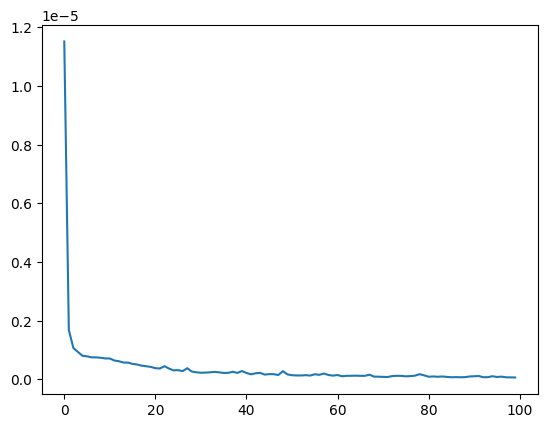

In [19]:
history = model.fit(X_train, y_train, epochs=100, verbose=1)
plt.plot(history.history['loss'], label='loss')
plt.show()

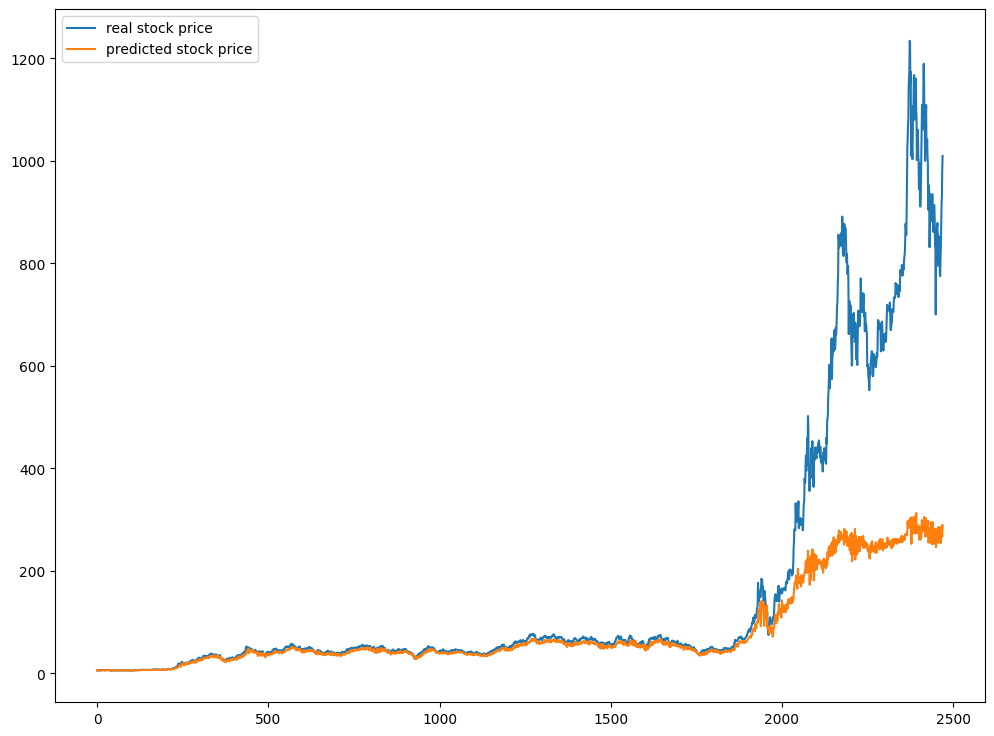

In [20]:
X_test, y_test = make_sample(test_data, 30)
y_pred = model.predict(X_test, verbose=0)
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)
plt.figure(figsize=(12, 9))
plt.plot(y_test_inv, label='real stock price')
plt.plot(y_pred_inv, label='predicted stock price')
plt.legend()
plt.show()